![Cabec%CC%A7alho_notebook.png](cabecalho_notebook.png)

# Classificação de Atividade Humana com PCA

Vamos trabalhar com a base da demonstração feita em aula, mas vamos explorar um pouco melhor como é o desempenho da árvore variando o número de componentes principais.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.tree import DecisionTreeClassifier

from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

filename_features = "./UCI HAR Dataset/features.txt"
filename_labels = "./UCI HAR Dataset/activity_labels.txt"

filename_subtrain = "./UCI HAR Dataset/train/subject_train.txt"
filename_xtrain = "./UCI HAR Dataset/train/X_train.txt"
filename_ytrain = "./UCI HAR Dataset/train/y_train.txt"

filename_subtest = "./UCI HAR Dataset/test/subject_test.txt"
ffilename_xtest = "./UCI HAR Dataset/test/X_test.txt"
filename_ytest = "./UCI HAR Dataset/test/y_test.txt"

features = pd.read_csv(filename_features, header=None, names=['nome_var'], sep="#")['nome_var']
labels = pd.read_csv(filename_labels, sep=r'\s+', header=None, names=['cod_label', 'label'])

subject_train = pd.read_csv(filename_subtrain, header=None, names=['subject_id'])['subject_id']
X_train = pd.read_csv(filename_xtrain, sep=r'\s+', header=None, names=features.tolist())
y_train = pd.read_csv(filename_ytrain, header=None, names=['cod_label'])

subject_test = pd.read_csv(filename_subtest, header=None, names=['subject_id'])['subject_id']
X_test = pd.read_csv(ffilename_xtest, sep=r'\s+', header=None, names=features.tolist())
y_test = pd.read_csv(filename_ytest, header=None, names=['cod_label'])

## PCA com variáveis padronizadas

Reflexão sobre a escala das variáveis:

**Variáveis em métricas muito diferentes** podem interferir na análise de componentes principais. Lembra que variância é informação pra nós? Pois bem, tipicamente se há uma variável monetária como salário, vai ter uma ordem de variabilidade bem maior que número de filhos, tempo de emprego ou qualquer variável dummy. Assim, as variáveis de maior variância tendem a "dominar" a análise. Nesses casos é comum usar a padronização das variáveis.

Faça duas análises de componentes principais para a base do HAR - com e sem padronização e compare:

- A variância explicada por componente
- A variância explicada acumulada por componente
- A variância percentual por componente
- A variância percentual acumulada por componente
- Quantas componentes você escolheria, em cada caso para explicar 90% da variância?

In [5]:
%%time

def padroniza(s):
    if s.std() > 0:
        s = (s - s.mean())/s.std()
    return s

X_train_pad = pd.DataFrame(X_train).apply(padroniza, axis=0)
X_train_pad.head()

CPU times: total: 234 ms
Wall time: 210 ms


,1 tBodyAcc-mean()-X,2 tBodyAcc-mean()-Y,3 tBodyAcc-mean()-Z,4 tBodyAcc-std()-X,5 tBodyAcc-std()-Y,6 tBodyAcc-std()-Z,7 tBodyAcc-mad()-X,8 tBodyAcc-mad()-Y,9 tBodyAcc-mad()-Z,10 tBodyAcc-max()-X,...,552 fBodyBodyGyroJerkMag-meanFreq(),553 fBodyBodyGyroJerkMag-skewness(),554 fBodyBodyGyroJerkMag-kurtosis(),"555 angle(tBodyAccMean,gravity)","556 angle(tBodyAccJerkMean),gravityMean)","557 angle(tBodyGyroMean,gravityMean)","558 angle(tBodyGyroJerkMean,gravityMean)","559 angle(X,gravityMean)","560 angle(Y,gravityMean)","561 angle(Z,gravityMean)"
0,0.200628,-0.063678,-0.419600,-0.868755,-0.939377,-0.737479,-0.859758,-0.938955,-0.766385,-0.855978,...,-0.795305,0.025958,-0.276380,-0.360579,0.062935,-0.778374,-0.026079,-0.687172,0.407918,-0.007567
1,0.055944,0.031484,-0.253891,-0.875366,-0.923839,-0.849247,-0.868472,-0.921936,-0.848870,-0.871300,...,0.130605,-0.897296,-0.767938,0.133002,-0.021460,-1.218722,1.484369,-0.694091,0.409089,0.007875
2,0.073510,-0.043414,-0.076289,-0.868980,-0.907698,-0.893724,-0.863078,-0.898793,-0.896640,-0.863264,...,1.152257,-0.260860,-0.438286,-0.377815,0.391949,0.151197,1.704085,-0.702191,0.410260,0.026501
3,0.066691,-0.208407,-0.249695,-0.870566,-0.939959,-0.921743,-0.864445,-0.938060,-0.925216,-0.863264,...,1.112694,0.591005,0.463123,-0.135016,-0.033635,1.037781,-1.002951,-0.701636,0.414622,0.031712
4,0.030467,0.027585,-0.109840,-0.875128,-0.934815,-0.921281,-0.867325,-0.931726,-0.927965,-0.870201,...,-0.149567,-0.138505,-0.240296,0.340383,0.268468,1.125841,-1.276196,-0.700104,0.425434,0.045222


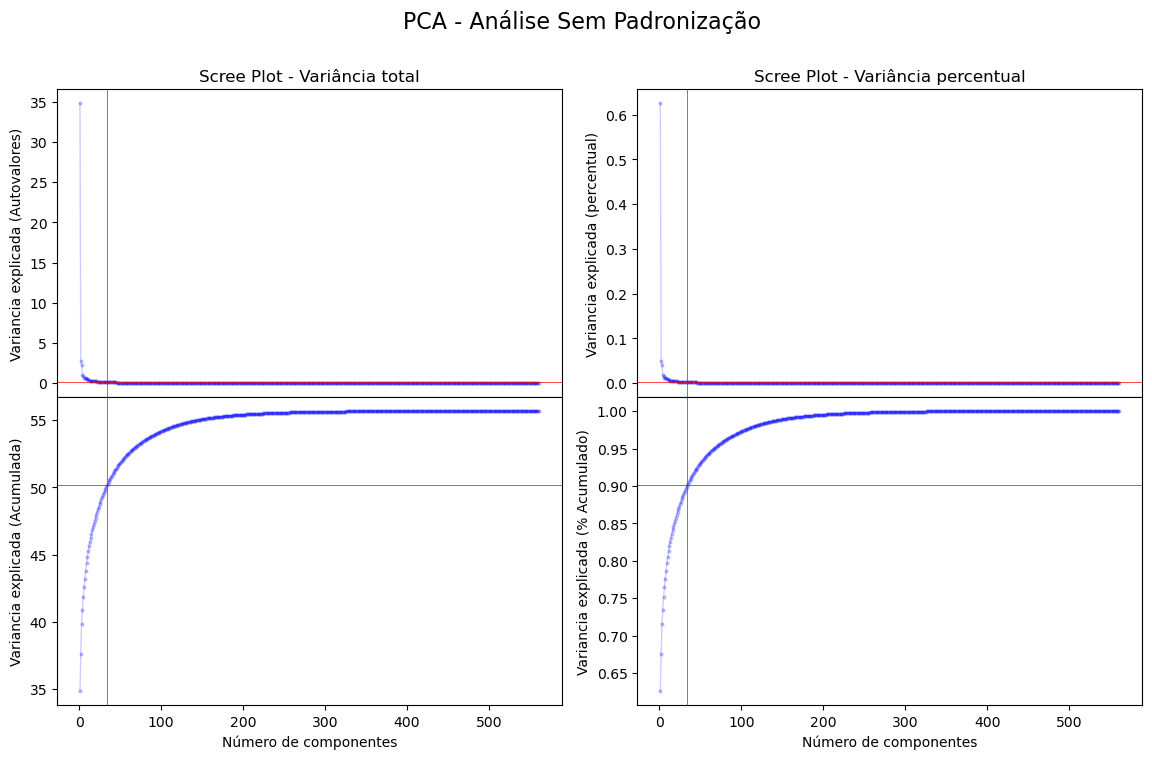

In [6]:
#PCA SEM padronização
pca_sem = PCA()
pca_sem.fit(X_train)

fig, ax = plt.subplots(2, 2, sharex=True, figsize=(14, 8))
plt.subplots_adjust(hspace=0, wspace=.15)

varexplicada = .90
ncomp = (pca_sem.explained_variance_ratio_.cumsum()<varexplicada).sum()+1

fig.suptitle('PCA - Análise Sem Padronização', fontsize=16)

#Gráfico da variância nominal por qtd-componentes
num_componentes = np.arange(pca_sem.n_components_) + 1
ax[0,0].plot(num_componentes, pca_sem.explained_variance_, 'o-', linewidth=1, color='blue', markersize=2, alpha=.2)
ax[0,0].set_title('Scree Plot - Variância total')
ax[0,0].set_xlabel('Número de componentes')
ax[0,0].set_ylabel('Variancia explicada (Autovalores)')

#Gráfico da variância nominal acumulada por qtd-componentes
ax[1,0].plot(num_componentes, pca_sem.explained_variance_.cumsum(), 'o-', linewidth=1, color='blue', markersize=2, alpha=.2)
ax[1,0].set_xlabel('Número de componentes')
ax[1,0].set_ylabel('Variancia explicada (Acumulada)')

#Gráfico da variância percentual por qtd-componentes
ax[0,1].plot(num_componentes, pca_sem.explained_variance_ratio_, 'o-', linewidth=1, color='blue', markersize=2, alpha=.2)
ax[0,1].set_title('Scree Plot - Variância percentual')
ax[0,1].set_xlabel('Número de componentes')
ax[0,1].set_ylabel('Variancia explicada (percentual)')

#Gráfico da variância percentual acumulada por qtd-componentes
ax[1,1].plot(num_componentes, pca_sem.explained_variance_ratio_.cumsum(), 'o-', linewidth=1, color='blue', markersize=2, alpha=.2)
ax[1,1].set_xlabel('Número de componentes')
ax[1,1].set_ylabel('Variancia explicada (% Acumulado)')

# linhas verticais de referência
ax[0,0].axvline(x = ncomp, color = 'r', linestyle = '-', linewidth=.5)
ax[1,1].axvline(x = ncomp, color = 'r', linestyle = '-', linewidth=.5)
ax[1,0].axvline(x = ncomp, color = 'r', linestyle = '-', linewidth=.5)
ax[0,1].axvline(x = ncomp, color = 'r', linestyle = '-', linewidth=.5)

# linhas horizontais
ax[0,0].axhline(y = pca_sem.explained_variance_[ncomp-1], color = 'r', linestyle = '-', linewidth=.5)
ax[1,0].axhline(y = pca_sem.explained_variance_.cumsum()[ncomp-1], color = 'r', linestyle = '-', linewidth=.5)
ax[0,1].axhline(y = pca_sem.explained_variance_ratio_[ncomp-1], color = 'r', linestyle = '-', linewidth=.5)
ax[1,1].axhline(y = pca_sem.explained_variance_ratio_.cumsum()[ncomp-1], color = 'r', linestyle = '-', linewidth=.5)

plt.show()

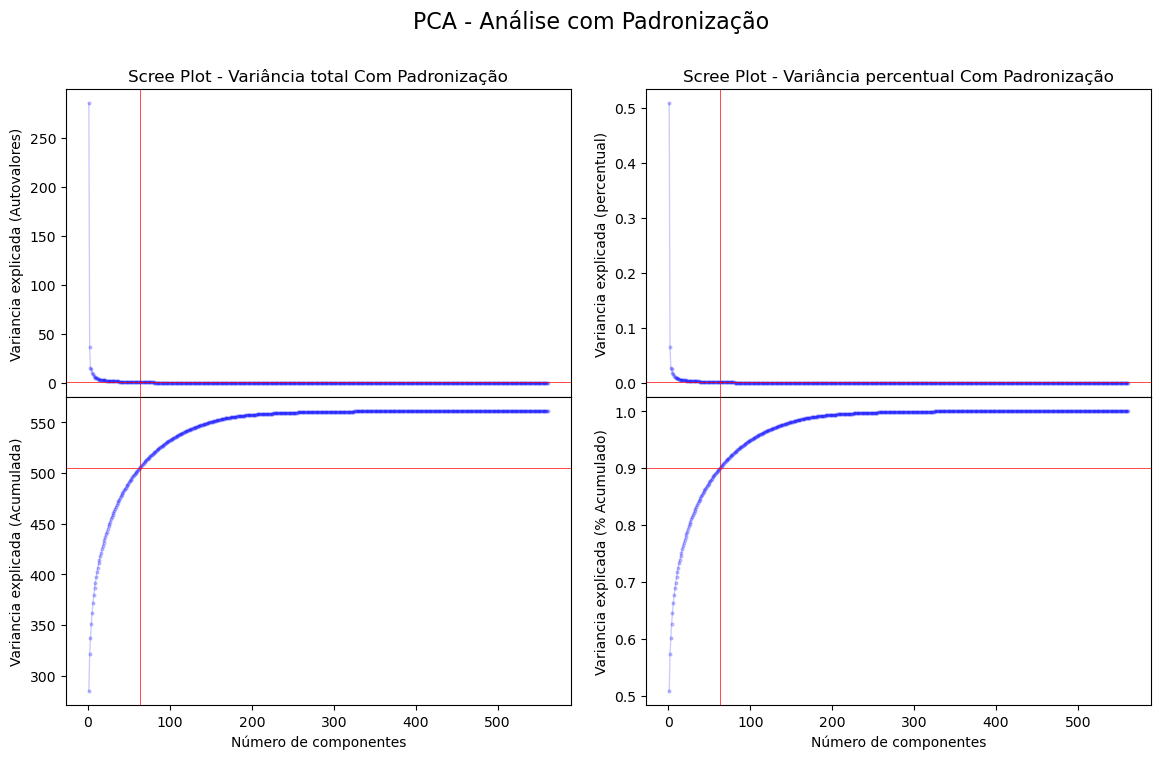

In [7]:
#PCA COM padronização
pca_com = PCA()
pca_com.fit(X_train_pad)

fig, ax = plt.subplots(2, 2, sharex=True, figsize=(14, 8))
plt.subplots_adjust(hspace=0, wspace=.15)

varexplicada = .90
ncomp_com = (pca_com.explained_variance_ratio_.cumsum()<varexplicada).sum()+1

fig.suptitle('PCA - Análise com Padronização', fontsize=16)

#Gráfico da variância nominal por qtd-componentes
num_componentes = np.arange(pca_com.n_components_) + 1
ax[0,0].plot(num_componentes, pca_com.explained_variance_, 'o-', linewidth=1, color='blue', markersize=2, alpha=.2)
ax[0,0].set_title('Scree Plot - Variância total Com Padronização')
ax[0,0].set_xlabel('Número de componentes')
ax[0,0].set_ylabel('Variancia explicada (Autovalores)')

#Gráfico da variância nominal acumulada por qtd-componentes
ax[1,0].plot(num_componentes, pca_com.explained_variance_.cumsum(), 'o-', linewidth=1, color='blue', markersize=2, alpha=.2)
ax[1,0].set_xlabel('Número de componentes')
ax[1,0].set_ylabel('Variancia explicada (Acumulada)')

#Gráfico da variância percentual por qtd-componentes
ax[0,1].plot(num_componentes, pca_com.explained_variance_ratio_, 'o-', linewidth=1, color='blue', markersize=2, alpha=.2)
ax[0,1].set_title('Scree Plot - Variância percentual Com Padronização')
ax[0,1].set_xlabel('Número de componentes')
ax[0,1].set_ylabel('Variancia explicada (percentual)')

#Gráfico da variância percentual acumulada por qtd-componentes
ax[1,1].plot(num_componentes, pca_com.explained_variance_ratio_.cumsum(), 'o-', linewidth=1, color='blue', markersize=2, alpha=.2)
ax[1,1].set_xlabel('Número de componentes')
ax[1,1].set_ylabel('Variancia explicada (% Acumulado)')

# linhas verticais de referência
ax[0,0].axvline(x = ncomp_com, color = 'r', linestyle = '-', linewidth=.5)
ax[1,1].axvline(x = ncomp_com, color = 'r', linestyle = '-', linewidth=.5)
ax[1,0].axvline(x = ncomp_com, color = 'r', linestyle = '-', linewidth=.5)
ax[0,1].axvline(x = ncomp_com, color = 'r', linestyle = '-', linewidth=.5)

# linhas horizontais
ax[0,0].axhline(y = pca_com.explained_variance_[ncomp_com-1], color = 'r', linestyle = '-', linewidth=.5)
ax[1,0].axhline(y = pca_com.explained_variance_.cumsum()[ncomp_com-1], color = 'r', linestyle = '-', linewidth=.5)
ax[0,1].axhline(y = pca_com.explained_variance_ratio_[ncomp_com-1], color = 'r', linestyle = '-', linewidth=.5)
ax[1,1].axhline(y = pca_com.explained_variance_ratio_.cumsum()[ncomp_com-1], color = 'r', linestyle = '-', linewidth=.5)

plt.show()

In [8]:
print(f'Número de componentes para explicar 90% da variância:')
print(f'- Sem padronização: {ncomp}')
print(f'- Com padronização: {ncomp_com}')

Número de componentes para explicar 90% da variância:
- Sem padronização: 34
- Com padronização: 63


### Conclusão
Com padronização, são necessárias mais componentes para explicar 90% da variância, indicando que as variáveis possuem escalas muito diferentes.  
Sem padronização, menos componentes explicam 90% da variância, porém isso ocorre porque algumas variáveis dominam a análise.  
Portanto, para uma análise mais equilibrada e representativa, o PCA **com padronização** é recomendado.


## Árvore com PCA

Faça duas uma árvore de decisão com 10 componentes principais - uma com base em dados padronizados e outra sem padronizar. Utilize o ```ccp_alpha=0.001```.

Compare a acurácia na base de treino e teste.

In [11]:
%%time

# PCA sem padronizar
pca_sem = PCA(n_components=10)
X_train_pca_sem = pca_sem.fit_transform(X_train)
X_test_pca_sem = pca_sem.transform(X_test)

# PCA com padronização
X_train_pad = pd.DataFrame(X_train).apply(padroniza, axis=0)
X_test_pad = pd.DataFrame(X_test).apply(padroniza, axis=0)

pca_com = PCA(n_components=10)
X_train_pca_com = pca_com.fit_transform(X_train_pad)
X_test_pca_com = pca_com.transform(X_test_pad)

CPU times: total: 1.41 s
Wall time: 487 ms


In [12]:
# Arvore de Decisao sem padronizar
arvore_sem = DecisionTreeClassifier(ccp_alpha=0.001, random_state=42)
arvore_sem.fit(X_train_pca_sem, y_train)

# Acuracia sem padronizar
y_train_pred_sem = arvore_sem.predict(X_train_pca_sem)
y_test_pred_sem = arvore_sem.predict(X_test_pca_sem)

acc_train_sem = accuracy_score(y_train, y_train_pred_sem)
acc_test_sem = accuracy_score(y_test, y_test_pred_sem)

In [13]:
# Arvore de Decisao com padronização
arvore_com = DecisionTreeClassifier(ccp_alpha=0.001, random_state=42)
arvore_com.fit(X_train_pca_com, y_train)

# Acuracia com Padronização
y_train_pred_com = arvore_com.predict(X_train_pca_com)
y_test_pred_com = arvore_com.predict(X_test_pca_com)

acc_train_com = accuracy_score(y_train, y_train_pred_com)
acc_test_com = accuracy_score(y_test, y_test_pred_com)

In [14]:
print("Arvore com PCA SEM padronizacao")
print(f"Acuracia Treino: {acc_train_sem*100:.2f}%")
print(f"Acuracia Teste: {acc_test_sem*100:.2f}%")

Arvore com PCA SEM padronizacao
Acuracia Treino: 89.27%
Acuracia Teste: 82.42%


In [15]:
print("Arvore com PCA COM padronizacao")
print(f"Acuracia Treino: {acc_train_com*100:.2f}%")
print(f"Acuracia Teste: {acc_test_com*100:.2f}%")

Arvore com PCA COM padronizacao
Acuracia Treino: 85.87%
Acuracia Teste: 77.37%


- A acuracia do treino SEM padronização é maior (89.27%), indicando que o modelo esta capturando melhor o padrao dentro da base de treino.
- A acuracia no teste SEM padronizacao é relativamente boa (82.47%), mas ainda com risco de overfitting.
- A acuracia do treino COM padronização é um pouco menor (85.87%), o que ja era esperado por que quando padronizamos acaba reduzindo a influencia de algumas variaveis dominantes, deixando o modelo mais simples.
- A acuracia no teste COM padronização é bem menor (77.37%), indicando que o modelo não conseguiu generalizar tão bem.